# Chapter 5: Deep Learning on Sequence Data

## Instructor: Rahul Bhadani

In [6]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
import polars as pl
import torch
import torch.nn as nn
import torch.optim as optim
# At the top of your notebook, add:
np.set_printoptions(suppress=True, precision=8)
torch.set_printoptions(sci_mode=False, precision=8)

import torch.nn.functional as F
from PIL import Image

cuda


# 1. Example of Filters

In [20]:
edge_filter = torch.tensor([[0, 1, 0],
                            [1, -4, 1],
                            [0, 1, 0]], dtype=torch.float32)

# Sobel - Horizontal
sobel_x = torch.tensor([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=torch.float32)

# Sobel - Vertical
sobel_y = torch.tensor([[1, 2, 1],
                        [0, 0, 0],
                        [-1, -2, -1]], dtype=torch.float32)

# Prewitt - Horizontal
prewitt_x = torch.tensor([[-1, 0, 1],
                        [-1, 0, 1],
                        [-1, 0, 1]], dtype=torch.float32)

# Prewitt - Vertical
prewitt_y = torch.tensor([[1, 1, 1],
                        [0, 0, 0],
                        [-1, -1, -1]], dtype=torch.float32)

# Roberts Cross (3x3 version) - Diagonal
roberts_x = torch.tensor([[0, 0, 0],
                        [0, 1, -1],
                        [0, 0, 0]], dtype=torch.float32)

# Roberts Cross (3x3 version) - Anti-diagonal
roberts_y = torch.tensor([[0, 0, 0],
                        [0, 1, 0],
                        [0, -1, 0]], dtype=torch.float32)

# Laplacian - 4-connectivity
laplacian_4 = torch.tensor([[0, 1, 0],
                            [1, -4, 1],
                            [0, 1, 0]], dtype=torch.float32)

# Laplacian - 8-connectivity
laplacian_8 = torch.tensor([[1, 1, 1],
                            [1, -8, 1],
                            [1, 1, 1]], dtype=torch.float32)

# Kirsch - North
kirsch_n = torch.tensor([[-3, -3, -3],
                        [-3, 0, -3],
                        [5, 5, 5]], dtype=torch.float32)

# Kirsch - East
kirsch_e = torch.tensor([[-3, -3, 5],
                        [-3, 0, 5],
                        [-3, -3, 5]], dtype=torch.float32)

# Robinson - North
robinson_n = torch.tensor([[-1, -2, -1],
                        [0, 0, 0],
                        [1, 2, 1]], dtype=torch.float32)

# Frei-Chen
frei_chen = torch.tensor([[1/torch.sqrt(torch.tensor(2.0)), 0, -1/torch.sqrt(torch.tensor(2.0))],
                        [1, 0, -1],
                        [1/torch.sqrt(torch.tensor(2.0)), 0, -1/torch.sqrt(torch.tensor(2.0))]], dtype=torch.float32)

sobel_filter = torch.tensor([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=torch.float32)

## Read an image

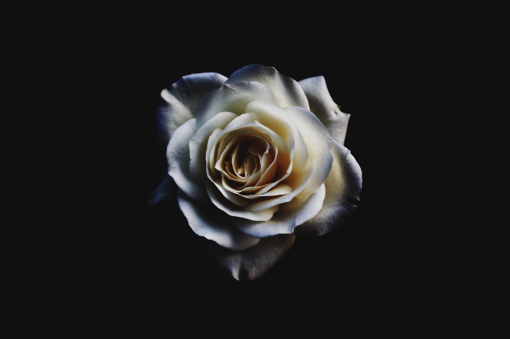

In [8]:
img = Image.open('rose.png').convert('RGB')
img

In [15]:
torch.from_numpy(np.array(img)).shape

torch.Size([339, 510, 3])

We want to change the order from Height x Width x  Channel to (Channels x Height x Width), or (Batch x Channels x Height x Width) for batches

In [17]:
img_tensor = torch.from_numpy(np.array(img)).float() / 255.0

# We want to change the order from Height x Width x  Channel to (Channels x Height x Width), or (Batch x Channels x Height x Width) for batches
img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)

img_tensor.shape

torch.Size([1, 3, 339, 510])

In [21]:
# Reshape filter: (1, 1, 3, 3) for conv2d
kernel = edge_filter.unsqueeze(0).unsqueeze(0)
kernel.shape

torch.Size([1, 1, 3, 3])

In [ ]:
# Apply filter to each channel
result_channels = []
for i in range(3):  # RGB
    
    # extracts single 4D Tensor Corresponding to each channel
    channel = img_tensor[:, i:i+1, :, :]
    
    # apply convolution 
    filtered = F.conv2d(channel, kernel, padding=1)
    result_channels.append(filtered)

In [23]:
# Combine channels
filtered_img = torch.cat(result_channels, dim=1)

In [24]:
# Convert back to numpy for saving/display
output = filtered_img.squeeze(0).permute(1, 2, 0).numpy()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.282353].


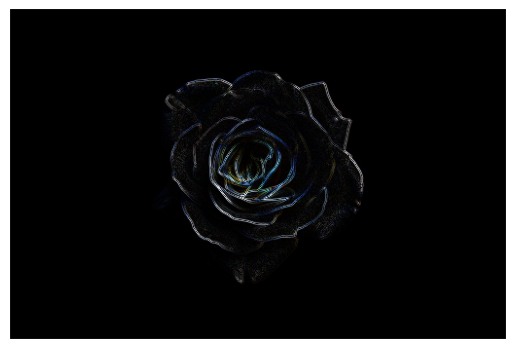

In [32]:
# Save or display
import matplotlib.pyplot as plt
plt.imshow(np.abs(output), cmap='gray')
plt.axis('off')
plt.show()

In [53]:
def apply_filter(img, filter):
    """
    Apply Filter to image

    Args:
        img (4 D Tensor): Input Image
        filter (4 D Tensor):  Input Filter
    """
    img_tensor = torch.from_numpy(np.array(img)).float() / 255.0
    img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0)
    kernel = filter.unsqueeze(0).unsqueeze(0)
    
    # Apply filter to each channel
    result_channels = []
    for i in range(3):  # RGB
        
        # extracts single 4D Tensor Corresponding to each channel
        channel = img_tensor[:, i:i+1, :, :]
        
        # apply convolution 
        filtered = F.conv2d(channel, kernel, padding=1)
        result_channels.append(filtered)
        
    # Combine channels
    filtered_img = torch.cat(result_channels, dim=1)
    
    # Convert back to numpy for saving/display
    output = filtered_img.squeeze(0).permute(1, 2, 0).numpy()
    
    # Normalize to [0, 1] range
    # because some filters produce values outside range 0 and 1
    #output = (output - output.min()) / (output.max() - output.min())
    
    # Save or display
    import matplotlib.pyplot as plt
    plt.imshow(output, cmap='gray')
    plt.axis('off')
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.282353..1.090196].


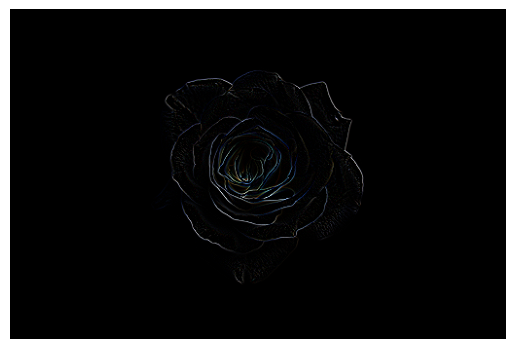

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.0509803..2.8313725].


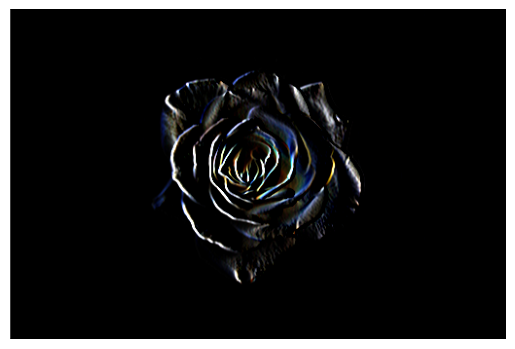

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.964706..3.152941].


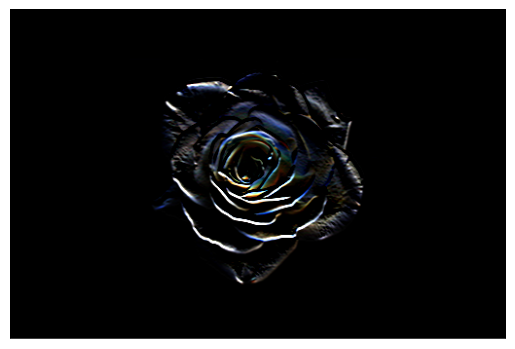

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2666664..2.1176472].


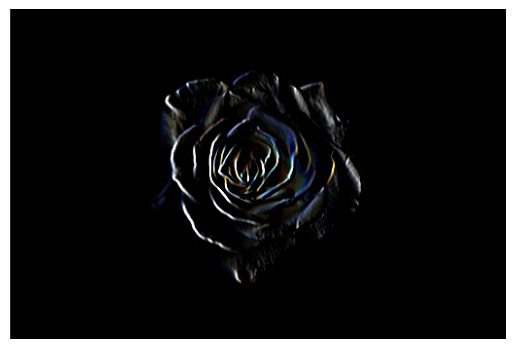

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.2117648..2.3647058].


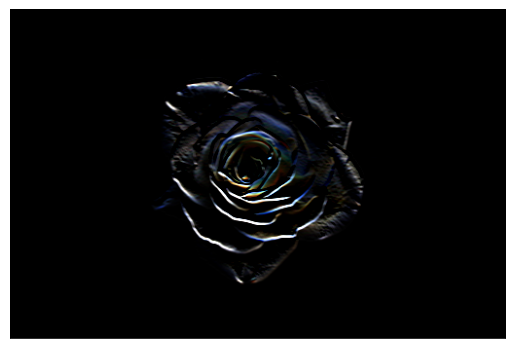

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.59607846..0.6].


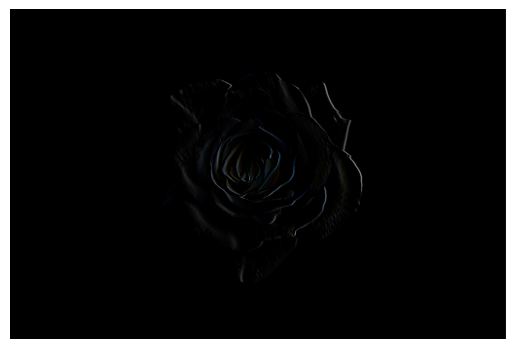

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5882353..0.6156863].


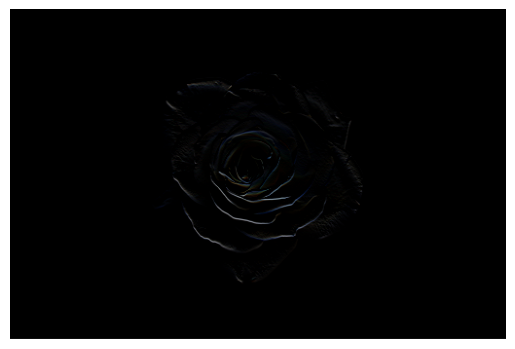

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.282353..1.090196].


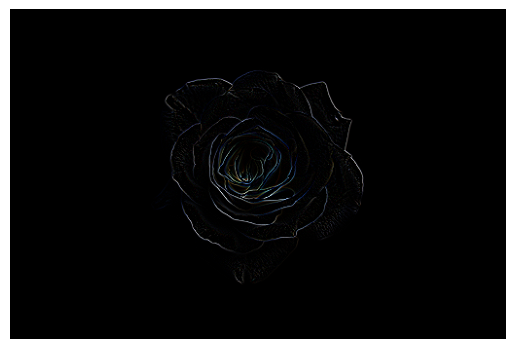

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.7843137..2.5411766].


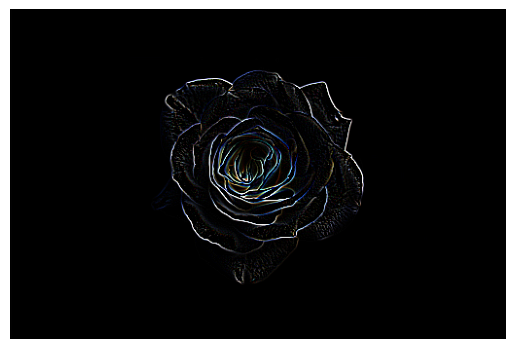

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-9.67451..9.819608].


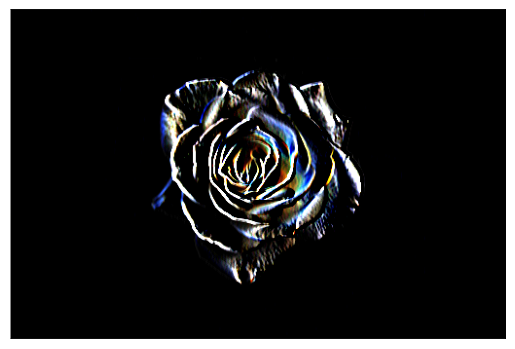

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-10.082354..9.57647].


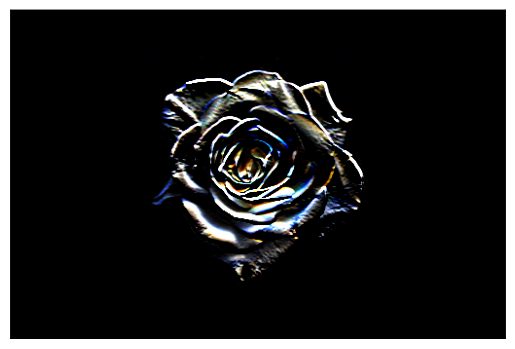

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.706448..1.8324955].


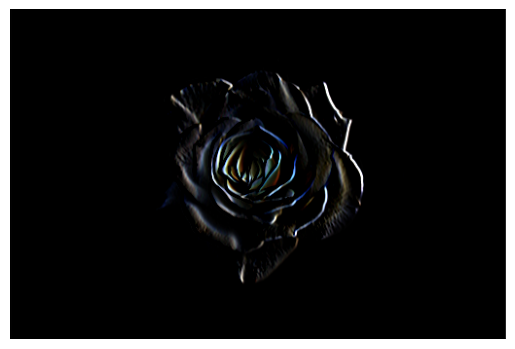

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.8313725..3.0509803].


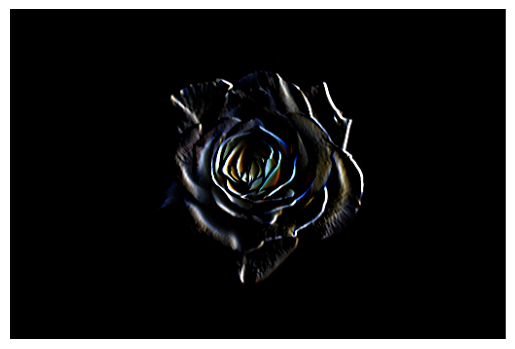

In [54]:
filters = [edge_filter, sobel_x, sobel_y,  prewitt_x, prewitt_y, roberts_x, roberts_y,laplacian_4, laplacian_8, kirsch_e, kirsch_n, frei_chen, sobel_filter]
for f in filters:
    apply_filter(img=img, filter=f)

# 2. Understanding Convolution Layer in PyTorch

`conv2d` in PyTorch

https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

It performs the following operation:

$$
(f*k)(i, j) = \sum_m \sum_n f(i+m, j + n) \cdot k(m, n)
$$

**Note:** The kernel is flipped in true mathematical convolution, but PyTorch does not flip the kernel – it performs cross‑correlation. This does not affect the network’s ability to learn because the kernels are learned from scratch.

In [73]:
import torch
import torch.nn as nn

# Create a Conv2d layer
conv = nn.Conv2d(in_channels=1,    # grayscale image
                    out_channels=4,   # number of filters
                    kernel_size=3,    # 3x3 kernel
                    stride=1,
                    padding=0)

# Random input: batch size 2, 1 channel, 5x6 image
x = torch.randn(2, 1, 5, 6)
print(f"x ={x}")
print("Input shape:  ", x.shape)


print(f"Convolution Weight: {conv.weight}")

print(f"Convolution Bias: {conv.bias}")

print(f"Convolution Weight Shape: {conv.weight.shape}")

# Forward pass
out = conv(x)
print("Output shape: ", out.shape)

x =tensor([[[[ 0.41379729,  1.03155148,  0.22919847,  0.73181093,  0.64246720,
            0.79322684],
          [-1.06939292,  1.90548754, -0.72204113, -0.68967211, -1.97749794,
           -1.55681801],
          [-0.66198260, -0.29574636, -1.22783136, -1.24253893,  1.77844334,
           -2.56380963],
          [-1.68637109, -0.07323001, -0.62540841, -1.04537189,  1.81005740,
            0.00799422],
          [ 0.75853336, -1.38228750, -0.09706402, -1.81493962,  0.76996607,
           -1.27611899]]],


        [[[-0.76104695, -1.47461390, -0.12094054, -1.04733443, -1.91292000,
           -0.60256791],
          [-0.43544710,  0.68425822,  0.28533730, -0.13499728,  0.02748727,
           -0.90892172],
          [-0.00959517, -1.90658188, -0.59096736, -1.38993871, -0.71143329,
           -1.97504723],
          [-1.59457135, -0.08784186,  0.68774992, -0.49934882, -1.93728971,
            0.06697761],
          [-1.16122890, -0.71184647, -1.51138294, -1.63926339, -0.43428802,
        

In [67]:
5 - 3 + 1,6 - 3 + 1

(3, 4)

We used 4 filters

Batch size stays 2

Hence: Output shape:  torch.Size([2, 4, 3, 4]) = batch_size  x filters x height x width

## Padding

Adding padding allows the convolution to be applied to border pixels and can keep the spatial size unchanged.

In [70]:
conv_pad = nn.Conv2d(1, 3, kernel_size=3, stride=1, padding=1)
out = conv_pad(x)
print("With padding=1:", out.shape)

With padding=1: torch.Size([2, 3, 5, 6])


## Stride
Stride > 1 down‑samples the feature map.

In [71]:
conv_stride2 = nn.Conv2d(1, 3, kernel_size=3, stride=2, padding=1)
out = conv_stride2(x)
print("Stride=2, padding=1:", out.shape)

Stride=2, padding=1: torch.Size([2, 3, 3, 3])


⌊(5+2−3)/2+1⌋=⌊4/2+1⌋=3.

## Learnable Parameters

Weight Tensor has shape :  no. of output channel x (input channel/groups) x kernesize[0] x kernelsize[1]

Bias Tensor is 1D Tensor of size of output channel

From documentation (https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html): 

`groups` controls the connections between inputs and outputs. `in_channels` and `out_channels` must both be divisible by groups. For example,

At `groups=1`, all inputs are convolved to all outputs.

At `groups=2`, the operation becomes equivalent to having two conv layers side by side, each seeing half the input channels and producing half the output channels, and both subsequently concatenated.

At `groups= in_channels`, each input channel is convolved with its own set of filters (of size `out_channels`/`in_channels`)



## Your own Conv2D

In [78]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Conv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super(Conv2d, self).__init__()
        
        # Store hyperparameters
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = kernel_size if isinstance(kernel_size, tuple) else (kernel_size, kernel_size)
        self.stride = stride if isinstance(stride, tuple) else (stride, stride)
        self.padding = padding if isinstance(padding, tuple) else (padding, padding)
        
        # Initialize learnable parameters
        self.weight = nn.Parameter(torch.randn(out_channels, in_channels, *self.kernel_size))
        if bias:
            self.bias = nn.Parameter(torch.zeros(out_channels))
        else:
            self.register_parameter('bias', None)
        
        # Initialize weights properly
        self.reset_parameters()
    
    def reset_parameters(self):
        # Kaiming initialization
        nn.init.kaiming_uniform_(self.weight, a=torch.nn.init.calculate_gain('relu'))
        if self.bias is not None:
            nn.init.zeros_(self.bias)
    
    def forward(self, x):
        # Use PyTorch's built-in conv2d function
        return F.conv2d(x, self.weight, self.bias, self.stride, self.padding)

# Usage example
conv = Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
x = torch.randn(1, 3, 32, 32)  # batch_size=1, channels=3, height=32, width=32
output = conv(x)
print(output.shape)  # torch.Size([1, 16, 32, 32])

torch.Size([1, 16, 32, 32])
